# Sampling the Gaia [alpha/M] posterior

Regression follow-up to exp6: the ray tracing sampler on a small MLP
posterior over Gaia XP spectra, with the priors done right this time. This
is the reference notebook for the exp7 workbook; the run happened on a
RunPod 5090 (about 4 GPU hours total) on 2026-07-26/27.

### Read this first

- Data: the Laroche and Speagle pristine cut reproduced at 126,156 stars
  (paper: 123,804). Target: predict APOGEE [alpha/M] from the 110 XP
  coefficients. Model: MLP 110-64-64-1 tanh, D = 11,329. Likelihood:
  Gaussian per star with sigma = the APOGEE label error. T = 1.
- The prior is the story. A Glorot per-layer prior puts the typical set
  where order-one networks live: the chain starts on its shell, no walk.
  The same sampler under the exp6 N(0,1) prior starts 99 percent saturated
  and, on the same budget, ends at 2.9x the misfit with a predictive that
  barely matches k-NN (section 4).
- The sampled net beats the k-NN baseline: RMSE 0.049 vs 0.074 (section 7).
- Eq. 33 is never an informative filter here: blind at the start
  (sigma_sto 26M nats), correctly all-rejecting at the fitted state, and
  when tuned by the paper's recipe (dt 5e-6) its acceptance equals its own
  noise ceiling, coin flips that slow the chain 20x without stopping the
  norm creep (sections 5 and 6). Its value was diagnostic, not corrective.
- Calibration says the uncertainties are 4x too small: the case for a
  learned intrinsic scatter of about 0.05 dex (section 7).

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

ROOT = Path.cwd() if (Path.cwd() / "experiments").exists() else Path.cwd().parent
TAB = ROOT / "results" / "tables"
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
GRAY, DARK, BLUE = "#9a9a9a", "#2b2b2b", "#3b6ea5"
LOG2PI = math.log(2 * math.pi)

d = np.load(TAB / "exp7_gaia_pristine.npz")
train_Xs, test_Xs = d["train_Xs"], d["test_Xs"]
train_y, test_y = d["train_y"], d["test_y"]
train_e, test_e = d["train_yerr"], d["test_yerr"]

CH_GATED_BLIND = TAB / "exp7_rt33_dt0.0001.npz"        # Glorot, descent, blind gate
CH_FROZEN     = TAB / "exp7_rt33_dt0.0001_part2.npz"   # all-reject leg
CH_UNGATED    = TAB / "exp7_rtub_dt0.0001.npz"         # Glorot, ungated control
CH_GATED_5E6  = TAB / "exp7_rt33_dt5e-06.npz"          # Glorot, working gate
CH_NORMAL     = TAB / "exp7n_rt33_dt0.0001.npz"        # N(0,1), same budget

def make_model():
    torch.manual_seed(0)
    return nn.Sequential(nn.Linear(110, 64), nn.Tanh(),
                         nn.Linear(64, 64), nn.Tanh(),
                         nn.Linear(64, 1)).to(DEV)

def glorot_sigmas(model, bias_sigma=0.1):
    return [math.sqrt(2.0 / (p.shape[1] + p.shape[0])) if p.ndim == 2
            else bias_sigma for p in model.parameters()]

def load_flat(model, flat):
    flat = torch.tensor(flat, dtype=torch.float32, device=DEV)
    i = 0
    with torch.no_grad():
        for p in model.parameters():
            p.copy_(flat[i:i + p.numel()].view(p.shape))
            i += p.numel()

@torch.no_grad()
def predictive(files, members=50):
    """Member predictions on the test split from the final quarter."""
    snaps = np.concatenate([np.load(f)["snapshots"] for f in files])
    quarter = snaps[3 * len(snaps) // 4:]
    take = np.linspace(0, len(quarter) - 1, min(members, len(quarter))).astype(int)
    model, X = make_model(), torch.tensor(test_Xs, device=DEV)
    mus = []
    for s in quarter[take]:
        load_flat(model, s)
        mus.append(model(X).squeeze(-1).cpu().numpy())
    mus = np.stack(mus)
    return mus.mean(axis=0), mus.std(axis=0)

D = sum(p.numel() for p in make_model().parameters())
print(f"train {len(train_Xs):,}  test {len(test_Xs):,}  D = {D:,}  device {DEV}")

train 100,924  test 25,232  D = 11,329  device mps


## 1. The sample

The paper's pristine cut, reproduced from its Section 2.2 recipe (label
precision, color, magnitude, and flag cuts; no Teff or logg cut, cool
giants emerge): 502,311 crossmatch, 126,156 pristine here vs 123,804 in the
paper. Split 80/20 with seed 2003, coefficients standardized on the
training split. The labels carry a median error of 0.006 against a spread
of 0.093: a factor 15 of usable information per star.

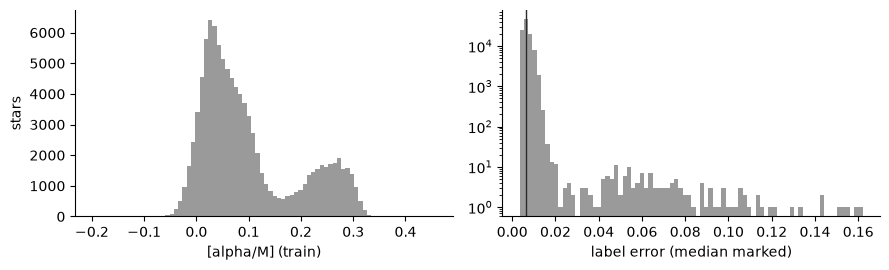

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].hist(train_y, bins=80, color=GRAY)
axes[0].set_xlabel("[alpha/M] (train)")
axes[0].set_ylabel("stars")
axes[1].hist(train_e, bins=80, color=GRAY, log=True)
axes[1].axvline(np.median(train_e), color=DARK, lw=1)
axes[1].set_xlabel("label error (median marked)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

## 2. The target

$$\ln p(\theta \mid \mathcal{D}) = -\Big[\sum_i
\frac{(y_i - \mu_\theta(x_i))^2}{2\,\mathrm{err}_i^2}
+ \ln \mathrm{err}_i + \tfrac{1}{2}\ln 2\pi\Big]
- \tfrac{1}{2}\sum_j \frac{\theta_j^2}{\sigma_j^2} + \text{const}$$

Gaussian likelihood with each star's own APOGEE error as sigma, T = 1,
and a per-layer Gaussian prior. The only difference from exp6 is the
likelihood line and the sigma vector; the sampler machinery is identical.

## 3. What each prior believes, before any data

Twenty networks drawn from each prior, run on the held-out spectra. The
N(0,1) prior (exp6's choice) drives every first-layer preactivation to
about 10 standard deviations, saturating every tanh: its typical network
is a random switchboard predicting order 10 when the labels span 0.6.
Glorot's variance, 2/(fan_in + fan_out), is precisely the choice that
keeps signals order one, so its prior predictive lands on the right scale
by construction. Same geometry, shells at raw norm-squared 11,329 vs 148,
just placed where different networks live.

typical |prediction|: N(0,1) 5.13, Glorot 0.29, labels 0.07


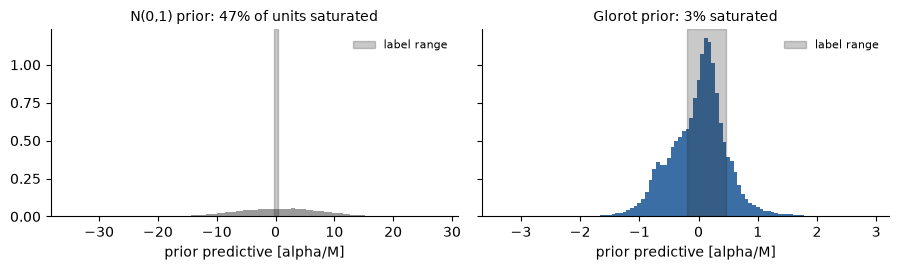

In [3]:
def prior_preds(sigmas_fn, n_draws=20):
    model = make_model()
    X = torch.tensor(test_Xs[:5000], device=DEV)
    sig = sigmas_fn(model)
    preds, sat = [], []
    g = torch.Generator(device="cpu").manual_seed(1)
    with torch.no_grad():
        for k in range(n_draws):
            for p, s in zip(model.parameters(), sig):
                p.copy_(torch.randn(p.shape, generator=g).to(DEV) * s)
            h = torch.tanh(model[0](X))
            sat.append((h.abs() > 0.99).float().mean().item())
            preds.append(model(X).squeeze(-1).cpu().numpy())
    return np.concatenate(preds), np.mean(sat)

pred_n, sat_n = prior_preds(lambda m: [1.0] * len(list(m.parameters())))
pred_g, sat_g = prior_preds(glorot_sigmas)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8), sharey=True)
axes[0].hist(pred_n, bins=100, color=GRAY, density=True)
axes[0].set_title(f"N(0,1) prior: {100*sat_n:.0f}% of units saturated", fontsize=10)
axes[1].hist(pred_g, bins=100, color=BLUE, density=True)
axes[1].set_title(f"Glorot prior: {100*sat_g:.0f}% saturated", fontsize=10)
for ax in axes:
    ax.axvspan(train_y.min(), train_y.max(), color=DARK, alpha=0.25,
               label="label range")
    ax.set_xlabel("prior predictive [alpha/M]")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print(f"typical |prediction|: N(0,1) {np.median(np.abs(pred_n)):.2f}, "
      f"Glorot {np.median(np.abs(pred_g)):.2f}, labels {np.median(np.abs(train_y)):.2f}")

## 4. Same sampler, same budget, two priors

The experiment: two chains with identical settings (minibatch Raytracer,
batch 1024, dt 1e-4, Eq. 33 checkpoints every 30 steps), each started from
a draw of its own prior, 500,000 steps each. The Glorot chain starts on
its shell and spends the budget fitting. The N(0,1) chain starts with 99
percent of its first-layer units saturated, where gradients are feeble,
and it shows: after the same 500,000 steps it sits at 2.9x the misfit
(4.78M vs 1.64M nats) with held-out RMSE 0.070, barely ahead of the k-NN
baseline the deep model is supposed to beat, against Glorot's 0.049. Both
chains sit faithfully on their own prior shells (right panel); the
difference is purely which networks live there. The prior is not a
detail: it decides what the entire budget buys.

final misfit: Glorot 1,644,134  N(0,1) 4,779,116


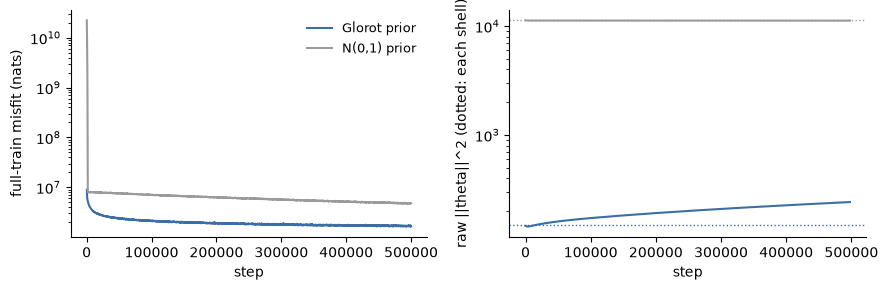

In [4]:
g1 = np.load(CH_GATED_BLIND)
n1 = np.load(CH_NORMAL)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
axes[0].semilogy(g1["steps"], g1["misfit"], color=BLUE, label="Glorot prior")
axes[0].semilogy(n1["steps"], n1["misfit"], color=GRAY, label="N(0,1) prior")
axes[0].set_xlabel("step")
axes[0].set_ylabel("full-train misfit (nats)")
axes[0].legend(frameon=False, fontsize=9)

sig_g = glorot_sigmas(make_model())
shell_glorot = sum(s**2 * n for s, n in zip(
    sig_g, [p.numel() for p in make_model().parameters()]))
rn_g = np.array([float((torch.tensor(s)**2).sum()) for s in g1["snapshots"][::10]])
rn_n = np.array([float((torch.tensor(s)**2).sum()) for s in n1["snapshots"][::10]])
axes[1].semilogy(g1["steps"][::10], rn_g, color=BLUE)
axes[1].semilogy(n1["steps"][::10], rn_n, color=GRAY)
axes[1].axhline(shell_glorot, color=BLUE, ls=":", lw=1)
axes[1].axhline(11329, color=GRAY, ls=":", lw=1)
axes[1].set_xlabel("step")
axes[1].set_ylabel("raw ||theta||^2 (dotted: each shell)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print(f"final misfit: Glorot {g1['misfit'][-1]:,.0f}  "
      f"N(0,1) {n1['misfit'][-1]:,.0f}")

## 5. The Eq. 33 gate: blind, then correct, then tuned

The gate compares a fresh one-batch estimate of the log posterior against
the sampler's own luminosity ledger every 30 steps, softened by
1/sqrt(1 + sigma_sto^2). Three regimes, all observed:

At the prior draw sigma_sto is 26M nats (the fit is terrible, batches
disagree wildly), the exponent is 4e-8, and the gate accepts everything.
At the fitted state sigma_sto drops to 135k, and at dt 1e-4 the gate
rejects every window: the ledger claims about 10M nats per window that
the estimates never see. Real irreversibility, correctly caught (left
panel). Lowering dt until acceptance recovers (the paper's own recipe,
applied at the fitted state where it can work) lands at dt = 5e-6 with
acceptance 0.36 (right panel). The plateau at 0.38 for smaller dt is the
gate's noise ceiling: with two independent batch estimates per window,
even a perfect chain loses 62 percent of its windows.

frozen leg: mean window ratio -10,317,504 nats, sigma_sto 135,305, acceptance 0.00


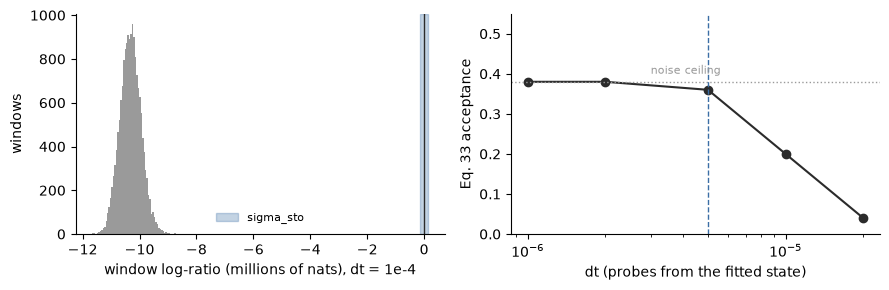

In [5]:
fr = np.load(CH_FROZEN)
raw = fr["window_raw"] / 1e6
sigma_sto = float(fr["sigma_sto"])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
axes[0].hist(raw, bins=60, color=GRAY)
axes[0].axvline(0, color=DARK, lw=1)
axes[0].axvspan(-sigma_sto / 1e6, sigma_sto / 1e6, color=BLUE, alpha=0.3,
                label="sigma_sto")
axes[0].set_xlabel("window log-ratio (millions of nats), dt = 1e-4")
axes[0].set_ylabel("windows")
axes[0].legend(frameon=False, fontsize=8)

dts = [2e-5, 1e-5, 5e-6, 2e-6, 1e-6]
accs = [0.04, 0.20, 0.36, 0.38, 0.38]
axes[1].semilogx(dts, accs, "o-", color=DARK)
axes[1].axhline(0.38, color=GRAY, ls=":", lw=1)
axes[1].annotate("noise ceiling", (3e-6, 0.40), fontsize=8, color=GRAY)
axes[1].axvline(5e-6, color=BLUE, ls="--", lw=1)
axes[1].set_xlabel("dt (probes from the fitted state)")
axes[1].set_ylabel("Eq. 33 acceptance")
axes[1].set_ylim(0, 0.55)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print(f"frozen leg: mean window ratio {raw.mean()*1e6:,.0f} nats, "
      f"sigma_sto {sigma_sto:,.0f}, acceptance {fr['window_accepted'].mean():.2f}")

## 6. The gated production chain at dt = 5e-6

Two million steps from the fitted state at the tuned step size. The
verdict is subtle: acceptance holds at 0.38, which is exactly the noise
ceiling from section 5, so the gate's decisions are statistically
indistinguishable from coin flips. It slows the chain (20x smaller steps,
62 percent of windows rejected at random) without policing anything: the
weighted norm still creeps, 19.2k to 24.4k over the two million steps.
And the price shows up in the members: the final-quarter spread collapses
to 0.002 because the chain barely moves. The honest reading: on this
target Eq. 33 is a diagnostic (its all-reject verdict at dt 1e-4 was
correct and useful), not a usable filter, and the knob-controlled
ungated chain remains the reference for posterior spread.

steps 2,000,000  acceptance 0.38  final misfit 1,405,228  final wnorm 24,399


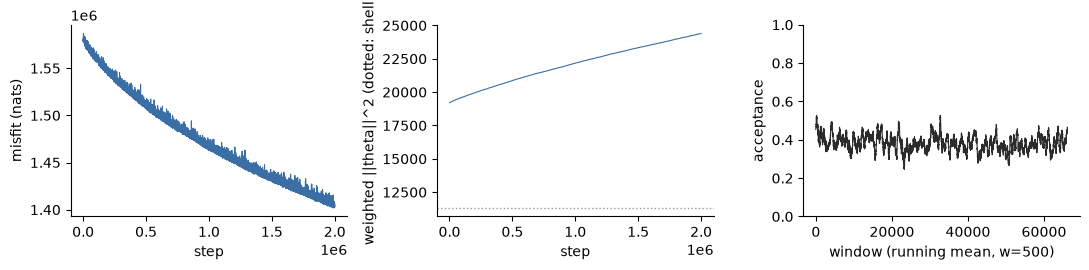

In [6]:
pr = np.load(CH_GATED_5E6)
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8))
axes[0].plot(pr["steps"], pr["misfit"], color=BLUE, lw=0.8)
axes[0].set_xlabel("step"); axes[0].set_ylabel("misfit (nats)")
axes[1].plot(pr["steps"], pr["wnorm"], color=BLUE, lw=0.8)
axes[1].axhline(11329, color=GRAY, ls=":", lw=1)
axes[1].set_xlabel("step"); axes[1].set_ylabel("weighted ||theta||^2 (dotted: shell)")
acc = pr["window_accepted"].astype(float)
w = 500
run_acc = np.convolve(acc, np.ones(w) / w, mode="valid")
axes[2].plot(run_acc, color=DARK, lw=0.8)
axes[2].set_xlabel(f"window (running mean, w={w})")
axes[2].set_ylabel("acceptance")
axes[2].set_ylim(0, 1)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print(f"steps {int(pr['n_steps']):,}  acceptance {acc.mean():.2f}  "
      f"final misfit {pr['misfit'][-1]:,.0f}  final wnorm {pr['wnorm'][-1]:,.0f}")

## 7. Scorecard

Held-out RMSE for every method, then calibration for the chains. The
sampled network beats k-NN comfortably under either Glorot chain; the
N(0,1) chain does not even reach the global-mean floor. Calibration: the
z scores should be N(0,1) if the total claimed uncertainty (member spread
plus label error) means anything. They are 4 to 6x too wide, the
concrete case for a learned intrinsic scatter s of about 0.05 dex, since
the residual RMSE is 0.049 against a claimed 0.010.

In [7]:
k = 10
Xtr = torch.tensor(train_Xs, device=DEV)
Xte = torch.tensor(test_Xs, device=DEV)
ytr = torch.tensor(train_y, device=DEV)
knn = torch.empty(len(test_Xs))
for i in range(0, len(test_Xs), 1024):
    dist = torch.cdist(Xte[i:i + 1024], Xtr)
    _, idx = torch.topk(dist, k, largest=False)
    knn[i:i + 1024] = ytr[idx].mean(dim=1).cpu()
knn = knn.numpy()

rows = {"global mean": np.full(len(test_y), train_y.mean()), "k-NN (k=10)": knn}
mu_n, tau_n = predictive([CH_NORMAL]);          rows["N(0,1) chain"] = mu_n
mu_u, tau_u = predictive([CH_UNGATED]);         rows["Glorot ungated"] = mu_u
mu_p, tau_p = predictive([CH_GATED_5E6]);       rows["Glorot gated 5e-6"] = mu_p

print(f"{'method':>20}  RMSE")
for name, mu in rows.items():
    print(f"{name:>20}  {np.sqrt(np.mean((mu - test_y) ** 2)):.4f}")

              method  RMSE
         global mean  0.0927
         k-NN (k=10)  0.0742
        N(0,1) chain  0.0704
      Glorot ungated  0.0486
   Glorot gated 5e-6  0.0492


member spread (median): ungated 0.0079, gated 0.0019; median label err 0.0064


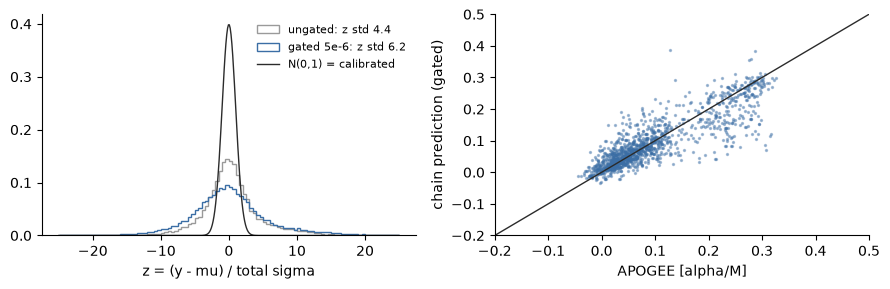

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
for mu, tau, c, label in ((mu_u, tau_u, GRAY, "ungated"),
                          (mu_p, tau_p, BLUE, "gated 5e-6")):
    z = (test_y - mu) / np.sqrt(tau ** 2 + test_e ** 2)
    axes[0].hist(z, bins=100, range=(-25, 25), density=True, histtype="step",
                 color=c, label=f"{label}: z std {z.std():.1f}")
grid = np.linspace(-25, 25, 400)
axes[0].plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), color=DARK, lw=1,
             label="N(0,1) = calibrated")
axes[0].set_xlabel("z = (y - mu) / total sigma")
axes[0].legend(frameon=False, fontsize=8)

axes[1].scatter(test_y[::20], mu_p[::20], s=2, color=BLUE, alpha=0.4)
lims = (-0.2, 0.5)
axes[1].plot(lims, lims, color=DARK, lw=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel("APOGEE [alpha/M]")
axes[1].set_ylabel("chain prediction (gated)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print(f"member spread (median): ungated {np.median(tau_u):.4f}, "
      f"gated {np.median(tau_p):.4f}; median label err {np.median(test_e):.4f}")

## 8. Looking at the spectra (GaiaXpy)

GaiaXpy turns the 110 coefficients back into calibrated flux against
wavelength (the first 55 are BP: swapping the halves produces a seam at
640 nm, so the order is confirmed). Calibration is linear in the
coefficients, which buys the third panel below: the network's input
gradient can itself be calibrated like a spectrum, giving the model's
sensitivity in wavelength space. Where the data says alpha lives (matched
stacks) and where the network looks (saliency) agree: the blue end.

Calibrating data:   0%|          | 0/107 [00:00<?, ?spec/s]

Calibrating data:   0%|          | 0/250 [00:00<?, ?spec/s]

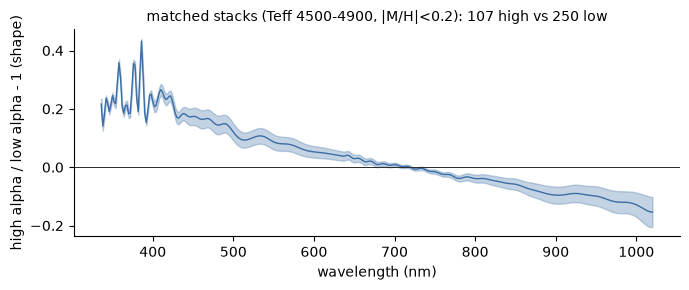

In [9]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from gaiaxpy import calibrate
plt.rcParams.update({"text.usetex": False})

sp = np.load(TAB / "exp7_gaia_spectra_payload.npz")
ZCORR = np.zeros(55 * 54 // 2)

def calib(rows_local, coeff_override=None):
    recs = []
    for j, r in enumerate(rows_local):
        c = sp["coeffs"][r] if coeff_override is None else coeff_override
        e = np.abs(sp["coeff_errs"][r]) + 1e-30
        recs.append(dict(source_id=int(sp["sids"][r]),
                         bp_n_parameters=55, rp_n_parameters=55,
                         bp_standard_deviation=1.0, rp_standard_deviation=1.0,
                         bp_coefficients=c[:55].astype(np.float64),
                         bp_coefficient_errors=e[:55].astype(np.float64),
                         bp_coefficient_correlations=ZCORR,
                         rp_coefficients=c[55:].astype(np.float64),
                         rp_coefficient_errors=e[55:].astype(np.float64),
                         rp_coefficient_correlations=ZCORR))
    cal, sampling = calibrate(pd.DataFrame.from_records(recs), save_file=False)
    return sampling, np.stack(cal["flux"].to_numpy()), np.stack(cal["flux_error"].to_numpy())

# matched stacks: same Teff and [M/H] box, split by alpha, shape only
box = ((sp["teff"] > 4500) & (sp["teff"] < 4900)
       & (sp["mh"] > -0.2) & (sp["mh"] < 0.2))
hi = np.flatnonzero(box & (test_y > 0.20))[:250]
lo = np.flatnonzero(box & (test_y < 0.06))[:250]
wl, fh, _ = calib(hi)
_, fl, _ = calib(lo)
fh /= fh.mean(axis=1, keepdims=True)
fl /= fl.mean(axis=1, keepdims=True)
rel = fh.mean(axis=0) / fl.mean(axis=0) - 1
rel_err = np.sqrt(fh.std(axis=0)**2 / len(fh) + fl.std(axis=0)**2 / len(fl))

fig, ax = plt.subplots(figsize=(7, 3.0))
ax.fill_between(wl, rel - rel_err, rel + rel_err, color=BLUE, alpha=0.3)
ax.plot(wl, rel, color=BLUE, lw=1)
ax.axhline(0, color=DARK, lw=0.7)
ax.set_xlabel("wavelength (nm)")
ax.set_ylabel("high alpha / low alpha - 1 (shape)")
ax.set_title(f"matched stacks (Teff 4500-4900, |M/H|<0.2): "
             f"{len(hi)} high vs {len(lo)} low", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

Calibrating data:   0%|          | 0/1 [00:00<?, ?spec/s]

Calibrating data:   0%|          | 0/1 [00:00<?, ?spec/s]

star card: APOGEE +0.068 +- 0.006, chain +0.055 +- 0.007 (the calibration gap, one star at a time)


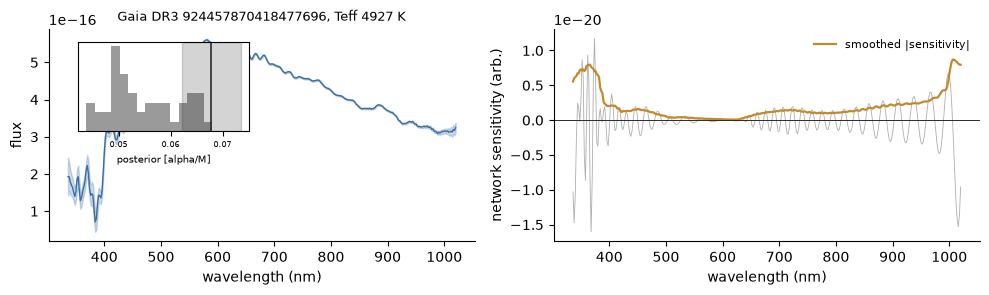

In [10]:
# star card: one giant's spectrum plus the chain's posterior for it,
# and the network saliency in wavelength space (linearity trick)
star = int(np.argsort(np.abs(test_y - np.median(test_y)))[0])
snaps_ub = np.load(CH_UNGATED)["snapshots"]
q = snaps_ub[3 * len(snaps_ub) // 4:]
model = make_model().cpu()
preds, grads = [], []
for s in q[np.linspace(0, len(q) - 1, 50).astype(int)]:
    i = 0
    with torch.no_grad():
        for p in model.parameters():
            p.copy_(torch.tensor(s[i:i + p.numel()]).view(p.shape)); i += p.numel()
    x = torch.tensor(test_Xs[star:star + 1]).requires_grad_(True)
    out = model(x).squeeze(); out.backward()
    preds.append(float(out)); grads.append(x.grad.numpy().ravel().copy())
preds = np.array(preds)
graw = np.mean(grads, axis=0) / d["norm_sd"]

wl, fs, fe = calib([star])
_, sal, _ = calib([star], coeff_override=graw)
sal = sal[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
axes[0].fill_between(wl, fs[0] - fe[0], fs[0] + fe[0], color=BLUE, alpha=0.25)
axes[0].plot(wl, fs[0], color=BLUE, lw=1)
axes[0].set_xlabel("wavelength (nm)"); axes[0].set_ylabel("flux")
axes[0].set_title(f"Gaia DR3 {sp['sids'][star]}, Teff {sp['teff'][star]:.0f} K",
                  fontsize=9)
ins = axes[0].inset_axes([0.07, 0.52, 0.4, 0.42])
ins.hist(preds, bins=15, color=GRAY)
ins.axvline(test_y[star], color=DARK, lw=1.2)
ins.axvspan(test_y[star] - test_e[star], test_y[star] + test_e[star],
            color=DARK, alpha=0.2)
ins.set_xlabel("posterior [alpha/M]", fontsize=7)
ins.tick_params(labelsize=6); ins.set_yticks([])

axes[1].plot(wl, sal, color=GRAY, lw=0.6, alpha=0.8)
w = 15
axes[1].plot(wl, np.sqrt(np.convolve(sal**2, np.ones(w) / w, mode="same")),
             color="#c08a2d", lw=1.6, label="smoothed |sensitivity|")
axes[1].axhline(0, color=DARK, lw=0.7)
axes[1].legend(frameon=False, fontsize=8)
axes[1].set_xlabel("wavelength (nm)")
axes[1].set_ylabel("network sensitivity (arb.)")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print(f"star card: APOGEE {test_y[star]:+.3f} +- {test_e[star]:.3f}, "
      f"chain {preds.mean():+.3f} +- {preds.std():.3f} "
      f"(the calibration gap, one star at a time)")

## Findings

**The prior decides what the budget buys.** Under Glorot the chain is
born on its shell and spends the entire budget fitting (RMSE 0.049);
under N(0,1) the same sampler and budget end at 2.9x the misfit, RMSE
0.070, barely at the k-NN level, with calibration twice as bad (z std
7.8 vs 4.4). exp6's 20,000-trajectory walk was not a sampler problem, it
was a prior problem.

**The chain beats the neighbor baseline.** RMSE 0.049 against k-NN's
0.074 and the global-mean 0.093, with a 11,329-parameter MLP.

**Eq. 33 is a diagnostic, not a filter, on this target.** From a prior
draw it is blind at every dt (sigma_sto 26M nats). At the fitted state it
correctly rejects the dt = 1e-4 dynamics wholesale (10M spurious nats per
window). Tuned by the paper's recipe to dt = 5e-6, its acceptance sits
exactly at its own noise ceiling (0.38), coin flips that slow mixing 20x,
collapse the member spread, and still fail to stop the norm creep. Two
lessons for free: tune acceptance only from a fitted state, and never
read a drift rule without the acceptance next to it, a frozen chain
passes any stationarity test.

**The uncertainties need an intrinsic scatter.** z std about 4 under
either Glorot chain: residuals 0.049 vs claimed 0.010. One extra sampled
parameter s (sigma_i^2 = err_i^2 + s^2) is the obvious next run.

## The bottom line

**Put the prior where sensible networks live and the walk disappears;
keep the Metropolis check and it will tell you, loudly, which step sizes
your minibatch dynamics can defend.**